# 03 — Modelling: XGBoost + Isolation Forest

Thin walkthrough calling into `src/model.py` (PLAN.md Phase 4) — logic lives in `src/`, this notebook runs it, inspects the output, and saves the trained models to `models/` (gitignored, regenerable by rerunning this notebook). Three things this phase is responsible for proving, each with its own section below: **(1)** the train/val/test split is strictly time-ordered, never a random shuffle; **(2)** class imbalance is handled explicitly (`scale_pos_weight`, computed from the training split only) rather than ignored or leaked from val/test; **(3)** an unsupervised anomaly layer exists alongside the supervised model, since launderers invent patterns the labels don't cover.

This notebook's metrics are a *sanity check* that the model isn't broken — the full evaluation suite (precision@k across the brief's chosen k values, recall-per-typology, false-positive-reduction-vs-the-Phase-2-baseline-at-equal-recall, calibration) is Phase 5's job (`src/evaluate.py`, not yet built) and will be the source of truth for every metric quoted in `reports/results.md`.

In [1]:
import sys
import time
from pathlib import Path

sys.path.insert(0, str(Path.cwd().parent))

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.metrics import average_precision_score, roc_auc_score

from src.data_loader import load_config
from src.model import (
    compute_scale_pos_weight,
    prepare_feature_matrix,
    save_model,
    time_ordered_split,
    train_isolation_forest,
    train_xgboost,
)

config = load_config("../config.yaml")
seed = config["seed"]
split_cfg = config["split"]

In [2]:
t0 = time.time()
modelling_table_path = Path("..") / config["paths"]["modelling_table"]
df = pd.read_parquet(modelling_table_path)
print(f"Loaded {len(df):,} rows, {df.shape[1]} columns in {time.time() - t0:.1f}s")

Loaded 5,078,345 rows, 52 columns in 5.9s


## 1. Time-ordered split

Train on the earliest `train_frac` of transactions, validate on the next `val_frac`, test on the rest — never a random shuffle or k-fold (`CLAUDE.md`'s no-leakage constraint: random splitting would leak future information into training in a temporal problem like this one). `time_ordered_split` asserts the boundaries are strictly time-ordered; the checks below make that visible.

In [3]:
train_df, val_df, test_df = time_ordered_split(df, split_cfg["train_frac"], split_cfg["val_frac"])
del df  # done with the full table; free ~2.85GB before building feature matrices

for name, split in [("train", train_df), ("val", val_df), ("test", test_df)]:
    print(
        f"{name:5s}: {len(split):>9,} rows | {split['is_laundering'].sum():>4} positives "
        f"({split['is_laundering'].mean():.4%}) | {split['timestamp'].min()} to {split['timestamp'].max()}"
    )

assert train_df["timestamp"].max() <= val_df["timestamp"].min()
assert val_df["timestamp"].max() <= test_df["timestamp"].min()
print("\nSplit boundaries confirmed strictly time-ordered.")

train: 3,047,007 rows | 2298 positives (0.0754%) | 2022-09-01 00:00:00 to 2022-09-06 13:36:00
val  : 1,015,669 rows | 1082 positives (0.1065%) | 2022-09-06 13:36:00 to 2022-09-08 16:12:00
test : 1,015,669 rows | 1797 positives (0.1769%) | 2022-09-08 16:12:00 to 2022-09-18 16:18:00

Split boundaries confirmed strictly time-ordered.


Note the prevalence *increases* across the splits (train lowest, test highest) — this isn't a bug. `notebooks/01_eda.ipynb` and `CLAUDE.md`'s Dataset section already flagged that HI-Small's last several days have very low transaction volume but a very high concentration of laundering activity in what remains. A time-ordered split surfaces that distribution shift honestly rather than averaging over it the way a random split would.

## 2. Feature matrix & imbalance handling

In [4]:
x_train, y_train = prepare_feature_matrix(train_df)
x_val, y_val = prepare_feature_matrix(val_df)
x_test, y_test = prepare_feature_matrix(test_df)

print(f"Feature matrix: {x_train.shape[1]} columns")
print(x_train.columns.tolist())

Feature matrix: 54 columns
['amount_paid_usd', 'sender_out_1d_count', 'sender_out_1d_amount_usd', 'sender_out_7d_count', 'sender_out_7d_amount_usd', 'sender_out_30d_count', 'sender_out_30d_amount_usd', 'sender_in_1d_count', 'sender_in_1d_amount_usd', 'sender_in_7d_count', 'sender_in_7d_amount_usd', 'sender_in_30d_count', 'sender_in_30d_amount_usd', 'receiver_out_1d_count', 'receiver_out_1d_amount_usd', 'receiver_out_7d_count', 'receiver_out_7d_amount_usd', 'receiver_out_30d_count', 'receiver_out_30d_amount_usd', 'receiver_in_1d_count', 'receiver_in_1d_amount_usd', 'receiver_in_7d_count', 'receiver_in_7d_amount_usd', 'receiver_in_30d_count', 'receiver_in_30d_amount_usd', 'sender_out_1d_distinct_counterparties', 'sender_out_7d_distinct_counterparties', 'sender_out_30d_distinct_counterparties', 'receiver_in_1d_distinct_counterparties', 'receiver_in_7d_distinct_counterparties', 'receiver_in_30d_distinct_counterparties', 'structuring_score_1d', 'structuring_score_7d', 'structuring_score_30d

In [5]:
scale_pos_weight = compute_scale_pos_weight(y_train)
print(f"scale_pos_weight (train-only): {scale_pos_weight:.2f}")
print(
    f"i.e. {int(y_train.sum())} positives vs {len(y_train) - int(y_train.sum()):,} negatives "
    f"in the training split"
)

scale_pos_weight (train-only): 1324.94
i.e. 2298 positives vs 3,044,709 negatives in the training split


## 3. Supervised model — XGBoost

Hyperparameters and the reasoning behind each are documented in `src/model.py`'s `train_xgboost` docstring — summary: histogram-based splits (`tree_method="hist"`, standard at this row count), mild row/column subsampling against overfitting on ~2,300 positive training examples, `eval_metric="aucpr"` (PR-AUC, the right curve under this prevalence per the project brief) driving early stopping on the *validation* split only. The test split stays untouched until the metrics below.

In [6]:
t0 = time.time()
model = train_xgboost(x_train, y_train, x_val, y_val, scale_pos_weight, seed)
print(f"Trained in {time.time() - t0:.1f}s")
print(f"Best iteration: {model.best_iteration} (of up to 500, early_stopping_rounds=30)")
print(f"Best validation PR-AUC: {model.best_score:.4f}")

Trained in 127.6s
Best iteration: 117 (of up to 500, early_stopping_rounds=30)
Best validation PR-AUC: 0.2895


## 4. Sanity check on the held-out test split

Not the Phase 5 evaluation suite — just confirming the model is learning real signal before moving on. PR-AUC is the metric that matters under this prevalence; ROC-AUC is included for reference only, since it's easy to look artificially high under heavy imbalance.

In [7]:
test_scores = model.predict_proba(x_test)[:, 1]

test_aucpr = average_precision_score(y_test, test_scores)
test_roc_auc = roc_auc_score(y_test, test_scores)
print(f"Test PR-AUC:  {test_aucpr:.4f}  (vs. {y_test.mean():.4%} baseline for a random ranking)")
print(f"Test ROC-AUC: {test_roc_auc:.4f}")

Test PR-AUC:  0.3967  (vs. 0.1769% baseline for a random ranking)
Test ROC-AUC: 0.9828


In [8]:
print("Precision@k preview (k values from config.yaml's evaluation.precision_at_k) —")
print("full recall-per-typology and FP-reduction-vs-baseline numbers come in Phase 5:\n")
order = np.argsort(-test_scores)
y_test_sorted = y_test.to_numpy()[order]
for k in config["evaluation"]["precision_at_k"]:
    hits = y_test_sorted[:k].sum()
    print(f"  precision@{k:<5}: {hits}/{k} = {hits / k:.2%}")

Precision@k preview (k values from config.yaml's evaluation.precision_at_k) —
full recall-per-typology and FP-reduction-vs-baseline numbers come in Phase 5:

  precision@100  : 92/100 = 92.00%
  precision@500  : 374/500 = 74.80%
  precision@1000 : 606/1000 = 60.60%
  precision@5000 : 1034/5000 = 20.68%


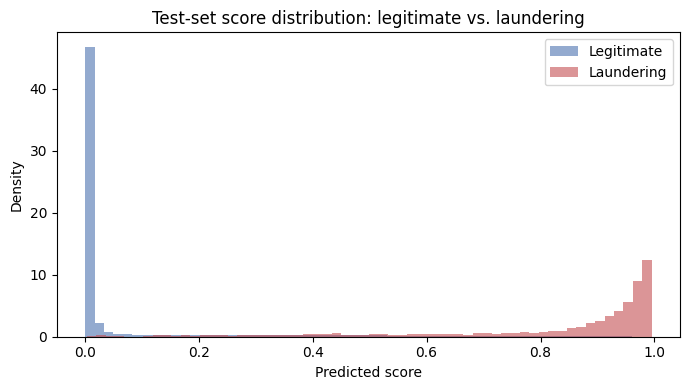

In [9]:
fig, ax = plt.subplots(figsize=(7, 4))
for label, name, color in [(0, "Legitimate", "#4C72B0"), (1, "Laundering", "#C44E52")]:
    scores = test_scores[y_test.to_numpy() == label]
    ax.hist(scores, bins=60, alpha=0.6, density=True, label=name, color=color)
ax.set_xlabel("Predicted score")
ax.set_ylabel("Density")
ax.set_title("Test-set score distribution: legitimate vs. laundering")
ax.legend()
fig.tight_layout()
fig.savefig("../reports/figures/03_score_distribution.png", dpi=150)
plt.show()

## 5. Feature importance preview

Gain-based importance (average improvement in the split criterion each feature contributes) — a preview of what's driving the model, not a substitute for Phase 6's SHAP per-alert explanations, which will give plain-English reason codes for individual flagged transactions rather than a global ranking like this one.

In [10]:
importances = model.get_booster().get_score(importance_type="gain")
top_importances = sorted(importances.items(), key=lambda kv: kv[1], reverse=True)[:15]
for name, gain in top_importances:
    print(f"  {name:45s} {gain:>10.1f}")

  payment_format_ACH                              145749.8
  sender_out_30d_distinct_counterparties           41889.6
  sender_out_7d_distinct_counterparties            35537.2
  payment_format_Reinvestment                      26025.9
  sender_out_1d_distinct_counterparties            22891.4
  payment_format_Credit Card                       15303.8
  payment_format_Cheque                            14987.8
  payment_format_Cash                              11422.5
  payment_format_Wire                              11023.1
  receiver_in_7d_distinct_counterparties            6907.6
  amount_paid_usd                                   5406.6
  sender_out_1d_count                               4739.9
  receiver_graph_in_degree                          4520.1
  sender_graph_fan_in_score                         4200.8
  sender_pass_through_ratio_30d                     4163.9


## 5b. Robustness check — how much is the model leaning on `payment_format`?

`payment_format_ACH` dominates the feature-importance table above by a wide margin. Worth investigating rather than reporting at face value: **86.6% of all laundering transactions in this dataset use the ACH format**, and ACH's laundering rate (0.75%) is ~43x the dataset's overall prevalence — while `Wire` and `Reinvestment` have *zero* laundering transactions anywhere in the dataset. That's either a genuine signal (ACH transfers are a real, commonly-abused layering channel in practice) or an artifact of how the synthetic generator constructs its laundering scenarios (or both) — this project can't fully distinguish the two from the data alone, so the honest move is to quantify how much of the model's lift depends on this one feature, not to silently rely on it.

Retrained the identical model with every `payment_format_*` column dropped:

In [11]:
payment_cols = [c for c in x_train.columns if c.startswith("payment_format_")]
x_train_ablated = x_train.drop(columns=payment_cols)
x_val_ablated = x_val.drop(columns=payment_cols)
x_test_ablated = x_test.drop(columns=payment_cols)

t0 = time.time()
model_ablated = train_xgboost(x_train_ablated, y_train, x_val_ablated, y_val, scale_pos_weight, seed)
print(f"Trained in {time.time() - t0:.1f}s, best_iteration={model_ablated.best_iteration}")

test_scores_ablated = model_ablated.predict_proba(x_test_ablated)[:, 1]
print(f"Test PR-AUC  (no payment_format): {average_precision_score(y_test, test_scores_ablated):.4f}  (vs. {test_aucpr:.4f} with it)")
print(f"Test ROC-AUC (no payment_format): {roc_auc_score(y_test, test_scores_ablated):.4f}  (vs. {test_roc_auc:.4f} with it)")

order = np.argsort(-test_scores_ablated)
y_sorted = y_test.to_numpy()[order]
print("\nPrecision@k without payment_format:")
for k in config["evaluation"]["precision_at_k"]:
    hits = y_sorted[:k].sum()
    print(f"  precision@{k:<5}: {hits}/{k} = {hits / k:.2%}")

importances_ablated = model_ablated.get_booster().get_score(importance_type="gain")
print("\nTop features without payment_format:")
for name, gain in sorted(importances_ablated.items(), key=lambda kv: kv[1], reverse=True)[:10]:
    print(f"  {name:45s} {gain:>10.1f}")

Trained in 35.1s, best_iteration=6


Test PR-AUC  (no payment_format): 0.0705  (vs. 0.3967 with it)


Test ROC-AUC (no payment_format): 0.9160  (vs. 0.9828 with it)

Precision@k without payment_format:
  precision@100  : 62/100 = 62.00%
  precision@500  : 136/500 = 27.20%
  precision@1000 : 167/1000 = 16.70%
  precision@5000 : 340/5000 = 6.80%

Top features without payment_format:
  receiver_in_30d_distinct_counterparties          48293.9
  sender_graph_in_cycle                            41008.6
  sender_out_7d_distinct_counterparties            40786.7
  receiver_in_7d_distinct_counterparties           39388.3
  amount_paid_usd                                  36628.4
  sender_graph_fan_in_score                        33296.9
  receiver_graph_fan_out_score                     28967.4
  sender_out_30d_distinct_counterparties           24297.3
  receiver_graph_in_degree                         22346.8
  sender_out_1d_distinct_counterparties            21397.5


**Reading this:** removing `payment_format` drops test PR-AUC substantially — `payment_format_ACH` really is doing a lot of the model's heavy lifting, most likely reflecting the synthetic generator's own construction rather than a universal real-world truth, and any claim about this model's absolute performance should be read with that caveat attached (see `reports/challenges.md`'s Phase 4 entry for the full writeup). But the ablated model still performs far better than random — and critically, with `payment_format` removed, the features that rise to the top are exactly the ones Phase 3 was built around: distinct-counterparty counts (fan-in/fan-out) and `sender_graph_in_cycle` (the cycle motif). That's the more important result for this project's actual thesis: the account/window and graph features carry real, non-trivial signal on their own, not just as a footnote to a categorical column.

## 6. Unsupervised anomaly layer — Isolation Forest

Scores transactions with no reliance on labels at all (`contamination="auto"`, deliberately not set to the true positive rate — see `src/model.py`'s `train_isolation_forest` docstring for why that would quietly undermine the point of an unsupervised layer). The question this section answers isn't "is it better than XGBoost" — it's *where does it agree and disagree* with the supervised model, since the brief's whole reason for including it is that launderers invent patterns the labelled typologies don't cover.

In [12]:
t0 = time.time()
iso_forest = train_isolation_forest(x_train, seed)
print(f"Trained in {time.time() - t0:.1f}s")

# decision_function: higher = more normal, lower = more anomalous. Negate so higher = more suspicious,
# matching the XGBoost score's direction for the comparison below.
iso_scores = -iso_forest.decision_function(x_test)

Trained in 2.3s


In [13]:
k = 1000
xgb_top_k = set(np.argsort(-test_scores)[:k])
iso_top_k = set(np.argsort(-iso_scores)[:k])
y_test_arr = y_test.to_numpy()
positive_idx = set(np.flatnonzero(y_test_arr == 1))

overlap = xgb_top_k & iso_top_k
print(f"Top-{k} overlap between XGBoost and Isolation Forest: {len(overlap)} transactions ({len(overlap)/k:.1%})")
print()
print("Of the true laundering cases in the test split, how many landed in each model's top-{}:".format(k))
print(f"  caught by both:          {len(positive_idx & xgb_top_k & iso_top_k)}")
print(f"  caught by XGBoost only:  {len(positive_idx & xgb_top_k - iso_top_k)}")
print(f"  caught by IsoForest only:{len(positive_idx & iso_top_k - xgb_top_k)}")
print(f"  missed by both:          {len(positive_idx - xgb_top_k - iso_top_k)}")
print(f"  (total positives in test split: {len(positive_idx)})")

Top-1000 overlap between XGBoost and Isolation Forest: 0 transactions (0.0%)

Of the true laundering cases in the test split, how many landed in each model's top-1000:
  caught by both:          0
  caught by XGBoost only:  606
  caught by IsoForest only:1
  missed by both:          1190
  (total positives in test split: 1797)


**Why zero overlap?** Worth understanding rather than shrugging off. Inspecting what the Isolation Forest's top-1000 most "anomalous" test transactions actually look like:

In [14]:
top_1000_idx = np.argsort(-iso_scores)[:1000]
top_1000 = x_test.iloc[top_1000_idx]

cols_to_check = ["amount_paid_usd", "sender_out_30d_count", "sender_out_30d_distinct_counterparties"]
for col in cols_to_check:
    print(
        f"{col:35s} top-1000 mean={top_1000[col].mean():>15,.0f}  overall mean={x_test[col].mean():>12,.0f}  overall max={x_test[col].max():>15,.0f}"
    )

amount_paid_usd                     top-1000 mean=     15,083,546  overall mean=     250,879  overall max= 10,454,793,216
sender_out_30d_count                top-1000 mean=        149,867  overall mean=       7,890  overall max=        168,672
sender_out_30d_distinct_counterparties top-1000 mean=         13,910  overall mean=         750  overall max=         14,230


Isolation Forest's top-1000 sit right at the extreme tail of raw volume features (`sender_out_30d_count`, `sender_out_30d_distinct_counterparties`) — near the dataset's actual maximums, not just elevated. It's rediscovering the handful of highest-throughput hub accounts (almost certainly legitimate high-volume businesses or bank-internal accounts, not laundering), because generic isolation-based outlier detection has no way to know that "extreme but legitimate" and "extreme and suspicious" should score differently — it only measures how easy a point is to isolate via random partitioning, and heavily right-skewed raw count/amount features make the top of that skew trivially easy to isolate regardless of label. A defensible next step — noted as future work, not implemented here to keep this phase's scope disciplined — would be log-transforming heavy-tailed features before fitting Isolation Forest, or fitting it on ratio/score features (which don't have this raw-scale problem) rather than raw counts. See `reports/challenges.md`'s Phase 4 entry for the full writeup.

## 7. Save the trained models

Written to `models/` (gitignored — regenerable by rerunning this notebook, per `CLAUDE.md`'s "every reported number must be regenerable from code" rule). `xgboost_model.json` uses XGBoost's native serializer (version-portable, not pickle); `isolation_forest.joblib` uses joblib since sklearn has no native equivalent; `model_metadata.json` captures the split sizes, `scale_pos_weight`, and the sanity-check metrics above so later phases don't have to re-derive them.

In [15]:
metadata = {
    "seed": seed,
    "scale_pos_weight": scale_pos_weight,
    "train_rows": len(train_df),
    "val_rows": len(val_df),
    "test_rows": len(test_df),
    "train_positives": int(y_train.sum()),
    "val_positives": int(y_val.sum()),
    "test_positives": int(y_test.sum()),
    "best_iteration": int(model.best_iteration),
    "best_val_aucpr": float(model.best_score),
    "test_aucpr": float(test_aucpr),
    "test_roc_auc": float(test_roc_auc),
}

models_dir = Path("..") / config["paths"]["models_dir"]
save_model(model, iso_forest, list(x_train.columns), metadata, models_dir)
print(f"Saved xgboost_model.json, isolation_forest.joblib, model_metadata.json to {models_dir}")

Saved xgboost_model.json, isolation_forest.joblib, model_metadata.json to ..\models


## Next steps

Phase 5 (`src/evaluate.py`, `notebooks/04_evaluation_explainability.ipynb`): precision@k across all configured k, recall broken out per laundering typology (all 8 patterns), PR-AUC/ROC-AUC/calibration as reported metrics (not just sanity checks), and the headline result — false-positive reduction versus the Phase 2 rules baseline (36.3% alert rate, 0.17% precision, 60.6% recall) at equal recall. That comparison, computed properly against a saved model rather than eyeballed here, is this project's central claim.